In [1578]:
# IMPORTS

import copy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import sage.all as sage
from sage.all import sin, cos, pi, ln, tanh, e
from Helpers.ic_generator import generate_ic_grid, get_ic_grid_info
from Helpers.state_helpers import StateAccessor
from Helpers.ode_viewer_nD import ODESystemND, ODEViewerND

In [1579]:
# CONFIGURATION

# ============================================================================
# ODE SYSTEM SETTINGS
# ============================================================================
N_VARS = 3  # Number of variables (not including t)

first_order_system = True  # Set to True for first-order systems like Lorenz
ode_order = N_VARS if not first_order_system else None

# ============================================================================
# TIME & INTEGRATION SETTINGS
# ============================================================================
t_start = 0.0  # Start time
t_end = 200.0  # End time
num_points = 4000  # Number of points for trajectory (higher = smoother)
step_size = 1e-12  # Integration step size (smaller = more accurate)

# Boundary cutoff (prevents unbounded growth in plots)
max_boundary = 200  # Maximum axis limit for plot boundaries (None = auto)
compute_boundary = 2 * max_boundary if max_boundary else None  # Stop computation when values exceed this

# ============================================================================
# INITIAL CONDITIONS
# ============================================================================
IC_CENTER = [10.0, 0.0, 0.0]  # Center of initial condition grid
IC_SPREAD = 0.0  # Spread around center (by unit)
ICS_PER_VAR = 1  # Number of ICs along each dimension

# ============================================================================
# VISUALIZATION SETTINGS
# ============================================================================
# Projection: which 3 variables to use as (x_axis, y_axis, z_axis) in 3D plot
# 0 = time, 1 = first var, 2 = second var, 3 = third var, ...
projection_axes = [0, 1, 2]  # Must have length 3 for 3D

# Coloring: which variable to color trajectories by (0 = time, 1 = x, 2 = y, ...) or None
color_by = 3

# Plot appearance
figsize = (7, 7)  # Figure size (width, height)
title = "Phase Space"  # Plot title
colormap_name = "viridis"  # Colormap: "viridis", "plasma", "inferno", "coolwarm", "RdYlBu", "twilight", etc.

# ============================================================================
# POINCARÉ SECTION SETTINGS
# ============================================================================
# Enable/disable Poincaré section visualization
show_poincare_section_2d = True  # Show 2D Poincaré plots
show_poincare_section_3d = True  # Show Poincaré points and plane in 3D viewer

# Plane equation: poincare_a*u + poincare_b*v + poincare_c*w + poincare_d = 0
# where (u,v,w) are the projected 3D coordinates
poincare_a, poincare_b, poincare_c, poincare_d = 0.0, 0.0, 1.0, 0.0
poincare_eps = 1e-18  # Tolerance for plane intersection tests (in projected coordinate units)

# Determine size of plane
plane_size = max_boundary * 0.8 if max_boundary else None
if plane_size is None:
    plane_size = t_end - t_start # manual plane_size if needed

# Output paths for 2D Poincaré section plots
poincare_2d_up_save = "./Plots/2D/poincare_plot_up.svg"
poincare_2d_down_save = "./Plots/2D/poincare_plot_down.svg"

# ============================================================================
# OUTPUT & DISPLAY SETTINGS
# ============================================================================
# Static 3D plot (matplotlib)
save_plot = True  # Save the 3D plot to a file
save_path = "./Plots/3D/3D_NSYS_ODE.png"

# Interactive 3D viewer (Three.js)
use_threejs = True
threejs_filename = "./Plots/3D/3D_NSYS_ODE.html"

# Point/marker sizing for plots
point_size = 15.0  # Point size for ICs and Poincaré intersection points


*---EXAMPLES---*

Example: Lorenz Attractor
```
def system_func(t, state):
  s = StateAccessor(state, VAR_NAMES)
  p = 10
  r = 28
  b = 8 / 3

  dx = p * (s.x_1 - s.x)
  dy = s.x * (r - s.x_2) - s.x_1
  dz = s.x * s.x_1 - b * s.x_2

  return [dx, dy, dz]
```

Example: Simple two city model
```
VAR_NAMES = ['P', 'E', 'M']
def system_func(t, state):
    s = StateAccessor(state, VAR_NAMES)

    carrying_cap = 1.0
    growth_rate = 0.3
    death_rate = 0.15
    capture_rate = 0.4
    war_money = 0.2

    dP = carrying_cap * tanh(growth_rate * s.E - capture_rate * s.M) - death_rate * s.P
    dE = carrying_cap * tanh(capture_rate * s.P) + war_money * s.M - growth_rate * s.E
    dM = carrying_cap * tanh(capture_rate * s.P + war_money * (s.M - s.E)) - (carrying_cap / 3) * tanh(s.P) * tanh(s.E)

    return [dP, dE, dM]
```

Example: Each variable's derivative is sine of the next variable
```
def system_func(t, state):
  s = StateAccessor(state, VAR_NAMES).to_list()
  derivs = []
  for i in range(N_VARS):
     next_idx = (i + 1) % N_VARS
     derivs.append(sin(s[i]))
   return derivs
```

In [1580]:
# VARIABLE NAMES
if first_order_system:
    VAR_NAMES = [
        f"x_{i}" if i > 0 else "x" for i in range(N_VARS)
    ]  # [x_1, x_2, x_3, ...]
else:
    VAR_NAMES = ["x"] + [
        ("d" * i) + "x" for i in range(1, ode_order)
    ]  # [x, dx, ddx, ...]

# OR DECLARE CUSTOM HERE:
VAR_NAMES = ["P", "E", "M"]

print(f"Using variables: {VAR_NAMES}")

Using variables: ['P', 'E', 'M']


In [1581]:
# FIRST ORDER SYSTEM DEFINITION

if first_order_system:
    # First-order system: define [dx/dt, dx₁/dt, dx₂/dt, ...]
    # state = [dx_1/dt, dx_2/dt, dx_3/dt, ...]
    def system_func(t, state):
        s = StateAccessor(state, VAR_NAMES)

        carrying_cap = 2.0

        pop_growth_rate = 0.8
        capture_rate = 0.6
        death_rate = 0.2

        eco_growth_rate = 0.8
        mil_budget = 0.35

        mil_pop = 0.5
        mob_pop = 0.4

        dP = carrying_cap * tanh(pop_growth_rate * s.E - capture_rate * s.M) - death_rate * s.P
        dE = carrying_cap * tanh(capture_rate * s.P) + mil_budget * s.M - eco_growth_rate * s.E
        dM = mil_pop * tanh(capture_rate * s.P + mil_budget * (s.M - s.E)) - mob_pop * tanh(s.P) * tanh(s.E)

        return [dP, dE, dM]

In [1582]:
# N ORDER SYSTEM DEFINITION

if not first_order_system:
    # Higher-order system: define dⁿx/dtⁿ
    # state = [x, dx/dt, d²x/dt², ..., dⁿ⁻¹x/dtⁿ⁻¹]
    def highest_derivative(t, state):
        s = StateAccessor(state, VAR_NAMES)

        return tanh(e ** -(s.ddx))

In [1583]:
# GENERATE INITIAL CONDITIONS

ic_grid = generate_ic_grid(N_VARS, IC_CENTER, IC_SPREAD, ICS_PER_VAR)
total_ics = get_ic_grid_info(N_VARS, ICS_PER_VAR)

print(f"System: {N_VARS}-variable system")
print(f"Variables: {VAR_NAMES}")
print(f"Initial conditions: {total_ics} trajectories")
print(f"IC grid: {len(ic_grid)} total points")
print(f"Time span: [{t_start}, {t_end}]")

System: 3-variable system
Variables: ['P', 'E', 'M']
Initial conditions: 1 trajectories
IC grid: 1 total points
Time span: [0.0, 200.0]


In [1584]:
# SOLVE

if first_order_system:
    system = ODESystemND(system_func, N_VARS, VAR_NAMES)
else:
    system = ODESystemND.from_higher_order(highest_derivative, ode_order, VAR_NAMES)

t_eval = np.linspace(t_start, t_end, num_points)
viewer = ODEViewerND()

viewer.solve_ics_grid(
    system,
    (t_start, t_end),
    ic_grid,
    total_ics,
    t_eval=t_eval,
)

print(f"✓ Solved {len(viewer.solutions)} trajectories")

Completed trajectory 1 of 1
✓ Solved 1 trajectories


In [1585]:
# POINCARÉ SECTION

poincare_points_3d_up = []
poincare_points_3d_down = []

for traj_idx, (sol, label) in enumerate(viewer.solutions):
    traj = sol.get_trajectory(compute_boundary=compute_boundary)
    for i in range(len(traj) - 1):
        p1 = traj[i]
        p2 = traj[i + 1]

        # skip invalid points
        try:
            u1 = float(p1[projection_axes[0]])
            v1 = float(p1[projection_axes[1]])
            w1 = float(p1[projection_axes[2]])
            u2 = float(p2[projection_axes[0]])
            v2 = float(p2[projection_axes[1]])
            w2 = float(p2[projection_axes[2]])
        except Exception:
            continue

        h1 = poincare_a * u1 + poincare_b * v1 + poincare_c * w1 + poincare_d
        h2 = poincare_a * u2 + poincare_b * v2 + poincare_c * w2 + poincare_d

        if h1 * h2 < 0:
            alpha = -h1 / (h2 - h1)
            u_int = u1 + alpha * (u2 - u1)
            v_int = v1 + alpha * (v2 - v1)
            w_int = w1 + alpha * (w2 - w1)

            # Interpolate color value at intersection point
            color_val = None
            if color_by is not None and color_by == 0:
                # Color by time
                color_val = p1[0] + alpha * (p2[0] - p1[0])
            elif color_by is not None and 0 < color_by <= N_VARS:
                # Color by state variable
                color_val = p1[color_by] + alpha * (p2[color_by] - p1[color_by])

            if h1 < -poincare_eps and h2 > poincare_eps:
                poincare_points_3d_up.append((u_int, v_int, w_int, traj_idx, color_val))
            elif h1 > poincare_eps and h2 < -poincare_eps:
                poincare_points_3d_down.append(
                    (u_int, v_int, w_int, traj_idx, color_val)
                )
        elif abs(h1) <= poincare_eps:
            # if exactly on plane, use neighbor to determine crossing
            color_val = None
            if color_by is not None and color_by == 0:
                color_val = p1[0]
            elif color_by is not None and 0 < color_by <= N_VARS:
                color_val = p1[color_by]

            if h2 > poincare_eps:
                poincare_points_3d_up.append((u1, v1, w1, traj_idx, color_val))
            elif h2 < -poincare_eps:
                poincare_points_3d_down.append((u1, v1, w1, traj_idx, color_val))

print(f"Found {len(poincare_points_3d_up)} upward crossings")
print(f"Found {len(poincare_points_3d_down)} downward crossings")

Found 2 upward crossings
Found 1 downward crossings


Saved Poincaré 2D plot to: ./Plots/2D/poincare_plot_up.svg


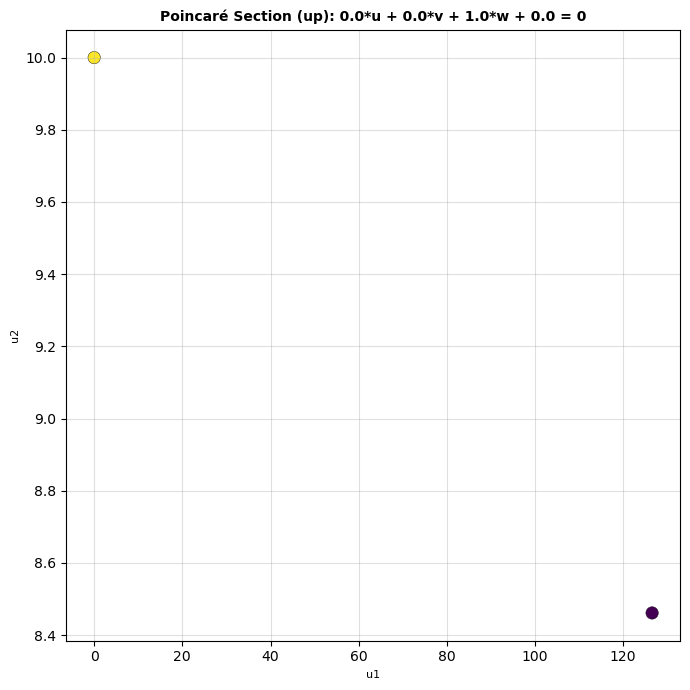

In [1586]:
# --- POINCARE PLOT (UP) ---
if show_poincare_section_2d and len(poincare_points_3d_up) > 0:
    normal = np.array([poincare_a, poincare_b, poincare_c], dtype=float)
    normal = normal / np.linalg.norm(normal)
    # choose a non-collinear reference vector
    if abs(normal[0]) < 0.9:
        vref = np.array([1.0, 0.0, 0.0])
    else:
        vref = np.array([0.0, 1.0, 0.0])

    u1 = vref - np.dot(vref, normal) * normal
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(normal, u1)
    u2 = u2 / np.linalg.norm(u2)

    plane_2d_coords = []
    for u, v, w, idx, color_val in poincare_points_3d_up:
        point_3d = np.array([u, v, w])
        # pick a reference point on the plane
        if abs(poincare_a) > 1e-12:
            ref_point = np.array([-poincare_d / poincare_a, 0.0, 0.0])
        elif abs(poincare_b) > 1e-12:
            ref_point = np.array([0.0, -poincare_d / poincare_b, 0.0])
        else:
            ref_point = np.array([0.0, 0.0, -poincare_d / poincare_c])

        vec_on_plane = point_3d - ref_point
        plane_2d_coords.append(
            (np.dot(vec_on_plane, u1), np.dot(vec_on_plane, u2), color_val)
        )

    cmap = plt.colormaps.get_cmap(colormap_name)

    u1_coords = [p[0] for p in plane_2d_coords]
    u2_coords = [p[1] for p in plane_2d_coords]

    # Color by the interpolated color value if available, else by trajectory
    color_vals = [p[2] for p in plane_2d_coords]
    if color_vals[0] is not None:
        # Normalize color values
        c_min = min(color_vals)
        c_max = max(color_vals)
        if c_max > c_min:
            normalized_colors = [(v - c_min) / (c_max - c_min) for v in color_vals]
        else:
            normalized_colors = [0.5 for v in color_vals]
        plot_colors = [cmap(nc) for nc in normalized_colors]
    else:
        plot_colors = "C0"

    plt.figure(figsize=figsize)
    plt.scatter(
        u1_coords,
        u2_coords,
        s=80,
        alpha=1.0,
        c=plot_colors,
        edgecolors="black",
        linewidth=0.3,
    )
    plt.xlabel("u1", fontsize=8)
    plt.ylabel("u2", fontsize=8)
    plane_eq = f"{poincare_a}*u + {poincare_b}*v + {poincare_c}*w + {poincare_d} = 0"
    plt.title(f"Poincaré Section (up): {plane_eq}", fontsize=10, fontweight="bold")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    try:
        plt.savefig(poincare_2d_up_save)
        print(f"Saved Poincaré 2D plot to: {poincare_2d_up_save}")
    except Exception:
        print("Could not save Poincaré 2D plot")
    plt.show()

Saved Poincaré 2D plot to: ./Plots/2D/poincare_plot_down.svg


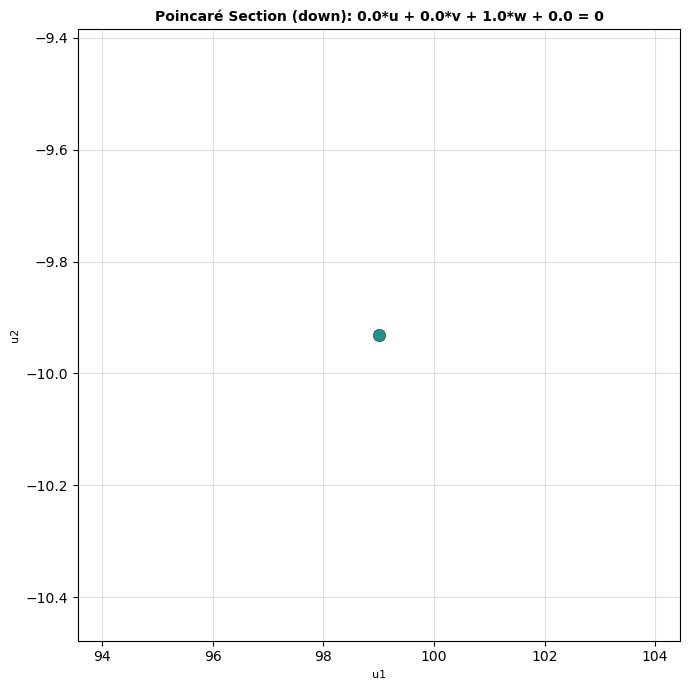

In [1587]:
# POINCARE PLOT (DOWN)
if show_poincare_section_2d and len(poincare_points_3d_down) > 0:
    normal = np.array([poincare_a, poincare_b, poincare_c], dtype=float)
    normal = normal / np.linalg.norm(normal)
    # choose a non-collinear reference vector
    if abs(normal[0]) < 0.9:
        vref = np.array([1.0, 0.0, 0.0])
    else:
        vref = np.array([0.0, 1.0, 0.0])

    u1 = vref - np.dot(vref, normal) * normal
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(normal, u1)
    u2 = u2 / np.linalg.norm(u2)

    plane_2d_coords = []
    for u, v, w, idx, color_val in poincare_points_3d_down:
        point_3d = np.array([u, v, w])
        # pick a reference point on the plane
        if abs(poincare_a) > 1e-12:
            ref_point = np.array([-poincare_d / poincare_a, 0.0, 0.0])
        elif abs(poincare_b) > 1e-12:
            ref_point = np.array([0.0, -poincare_d / poincare_b, 0.0])
        else:
            ref_point = np.array([0.0, 0.0, -poincare_d / poincare_c])

        vec_on_plane = point_3d - ref_point
        plane_2d_coords.append(
            (np.dot(vec_on_plane, u1), np.dot(vec_on_plane, u2), color_val)
        )

    cmap = plt.colormaps.get_cmap(colormap_name)

    u1_coords = [p[0] for p in plane_2d_coords]
    u2_coords = [p[1] for p in plane_2d_coords]

    # Color by the interpolated color value if available, else by trajectory
    color_vals = [p[2] for p in plane_2d_coords]
    if color_vals[0] is not None:
        # Normalize color values
        c_min = min(color_vals)
        c_max = max(color_vals)
        if c_max > c_min:
            normalized_colors = [(v - c_min) / (c_max - c_min) for v in color_vals]
        else:
            normalized_colors = [0.5 for v in color_vals]
        plot_colors = [cmap(nc) for nc in normalized_colors]
    else:
        plot_colors = "C0"

    plt.figure(figsize=figsize)
    plt.scatter(
        u1_coords,
        u2_coords,
        s=80,
        alpha=1.0,
        c=plot_colors,
        edgecolors="black",
        linewidth=0.3,
    )
    plt.xlabel("u1", fontsize=8)
    plt.ylabel("u2", fontsize=8)
    plane_eq = f"{poincare_a}*u + {poincare_b}*v + {poincare_c}*w + {poincare_d} = 0"
    plt.title(f"Poincaré Section (down): {plane_eq}", fontsize=10, fontweight="bold")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    try:
        plt.savefig(poincare_2d_down_save)
        print(f"Saved Poincaré 2D plot to: {poincare_2d_down_save}")
    except Exception:
        print("Could not save Poincaré 2D plot")
    plt.show()

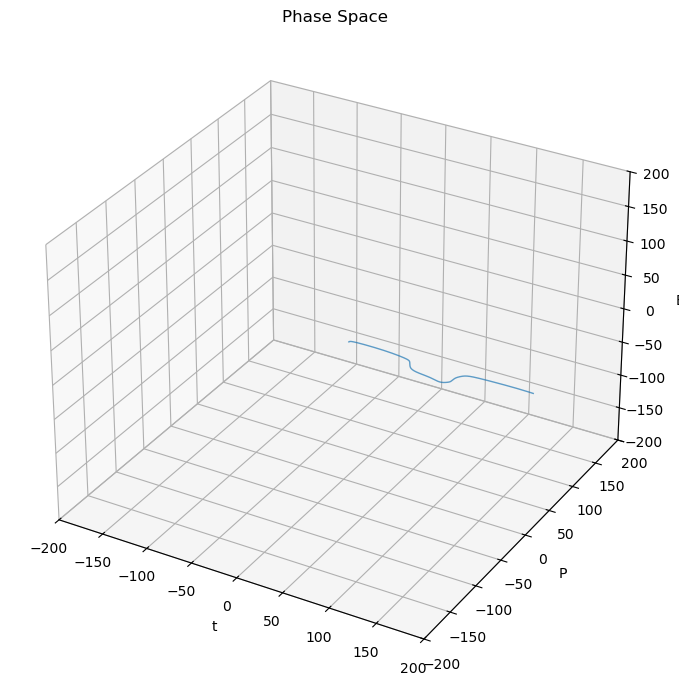

✓ Plotted phase space with projection axes [0, 1, 2]


In [1588]:
# PLOTTING

viewer.plot_all_3d(
    projection_axes=projection_axes,
    color_variable=color_by,
    figsize=figsize,
    title=title,
    save_path=save_path if save_plot else None,
    max_boundary=max_boundary,
    compute_boundary=compute_boundary,
)

print(f"✓ Plotted phase space with projection axes {projection_axes}")

In [1589]:
# THREE.JS INTERACTIVE VIEWER

if use_threejs:
    cmap = plt.colormaps.get_cmap(colormap_name)

    def norm_to_rgb(norm_val):
        rgba = cmap(norm_val)
        return tuple(rgba[:3])  # Return (R, G, B) as 0-1 floats

    def rgb_to_hex(rgb):
        r, g, b = [int(round(x * 255)) for x in rgb]
        return f"#{r:02x}{g:02x}{b:02x}"

    traj_data = viewer.get_threejs_trajectories(
        projection_axes=projection_axes,
        color_variable=color_by,
        compute_boundary=compute_boundary,
    )

    plot_obj = sage.Graphics()

    all_color_values = []
    if color_by is not None:
        for traj in traj_data:
            if traj.get("color_values"):
                all_color_values.extend(traj["color_values"])

    for idx, traj in enumerate(traj_data):
        points = traj["points"]

        if color_by is not None and traj.get("normalized_colors") is not None:
            colors = traj["normalized_colors"]
            for i in range(0, len(points) - 1):
                color_val = colors[i]
                rgb = norm_to_rgb(color_val)
                segment = sage.line3d(
                    [points[i], points[i + 1]],
                    color=rgb_to_hex(rgb),
                    thickness=2,
                    opacity=0.8,
                )
                plot_obj += segment
        else:
            traj_color = traj.get("trajectory_color", 0)
            rgb = norm_to_rgb(traj_color)
            line = sage.line3d(
                points,
                color=rgb_to_hex(rgb),
                thickness=2,
                opacity=0.8,
            )
            plot_obj += line

    if color_by is not None and all_color_values:
        c_min = min(all_color_values)
        c_max = max(all_color_values)
        color_label = VAR_NAMES[color_by - 1] if 0 < color_by <= N_VARS else "time"

        pos_base = max_boundary if max_boundary else 20
        bar_x = pos_base
        bar_y = pos_base
        bar_z_start = -max_boundary // 2 if max_boundary else -10
        bar_z_end = max_boundary // 2 if max_boundary else 10
        bar_length = bar_z_end - bar_z_start

        n_segments = 20
        for i in range(n_segments):
            norm_val = i / (n_segments - 1) if n_segments > 1 else 0
            z_pos = bar_z_start + norm_val * bar_length
            z_next = (
                bar_z_start + ((i + 1) / (n_segments - 1)) * bar_length
                if i < n_segments - 1
                else bar_z_end
            )

            rgb = norm_to_rgb(norm_val)
            segment = sage.line3d(
                [[bar_x, bar_y, z_pos], [bar_x, bar_y, z_next]],
                color=rgb_to_hex(rgb),
                thickness=10,
            )
            plot_obj += segment

        print(max)
        plot_obj += sage.text3d(
            color_label,
            (bar_x + (1 / pos_base), bar_y, bar_z_end - bar_length / 2),
            fontsize=12,
            color="black",
        )
        plot_obj += sage.text3d(
            f"{c_max:.2f}",
            (bar_x + (1 / pos_base), bar_y, bar_z_end),
            fontsize=10,
            color="black",
        )
        plot_obj += sage.text3d(
            f"{c_min:.2f}",
            (bar_x + (1 / pos_base), bar_y, bar_z_start),
            fontsize=10,
            color="black",
        )

        print(
            f"Color by: {color_by} ({color_label}), range: [{c_min:.2f}, {c_max:.2f}]"
        )
        print(f"Colormap: {colormap_name}")
    elif color_by is not None:
        print(
            f"Color by: {color_by} ({VAR_NAMES[color_by-1] if 0 < color_by <= N_VARS else 'time'})"
        )

    if show_poincare_section_3d and any([poincare_a, poincare_b, poincare_c]):
        try:
            normal = np.array([poincare_a, poincare_b, poincare_c], dtype=float)
            norm_len = np.linalg.norm(normal)
            if norm_len > 0:
                normal = normal / norm_len
                if abs(normal[0]) < 0.9:
                    vref = np.array([1.0, 0.0, 0.0])
                else:
                    vref = np.array([0.0, 1.0, 0.0])
                u_axis = vref - np.dot(vref, normal) * normal
                u_axis = u_axis / np.linalg.norm(u_axis)
                v_axis = np.cross(normal, u_axis)
                v_axis = v_axis / np.linalg.norm(v_axis)

                if abs(poincare_a) > 1e-12:
                    ref_point = np.array([-poincare_d / poincare_a, 0.0, 0.0])
                elif abs(poincare_b) > 1e-12:
                    ref_point = np.array([0.0, -poincare_d / poincare_b, 0.0])
                else:
                    ref_point = np.array([0.0, 0.0, -poincare_d / poincare_c])
                n_grid = 8
                for i in range(n_grid):
                    for j in range(n_grid):
                        u_val = -plane_size + (2 * plane_size * i / (n_grid - 1))
                        v_val = -plane_size + (2 * plane_size * j / (n_grid - 1))
                        p = ref_point + u_val * u_axis + v_val * v_axis

                        if i < n_grid - 1:
                            u_val_next = -plane_size + (
                                2 * plane_size * (i + 1) / (n_grid - 1)
                            )
                            p_next = ref_point + u_val_next * u_axis + v_val * v_axis
                            plot_obj += sage.line3d(
                                [list(p), list(p_next)],
                                color="#ff0000",
                                thickness=0.5,
                                opacity=0.4,
                            )

                        if j < n_grid - 1:
                            v_val_next = -plane_size + (
                                2 * plane_size * (j + 1) / (n_grid - 1)
                            )
                            p_next = ref_point + u_val * u_axis + v_val_next * v_axis
                            plot_obj += sage.line3d(
                                [list(p), list(p_next)],
                                color="#ff0000",
                                thickness=0.5,
                                opacity=0.4,
                            )
        except Exception as e:
            print(f"Could not add plane surface: {e}")

    if show_poincare_section_3d:
        all_p_pts = []
        try:
            all_p_pts = poincare_points_3d_up + poincare_points_3d_down
        except NameError:
            all_p_pts = []

        for pt in all_p_pts:
            # pt = (u, v, w, traj_idx, color_val) in projected coords
            traj_idx = int(pt[3])
            color_val = pt[4] if len(pt) > 4 else None

            if color_val is not None and color_by is not None:
                # Use the interpolated color value
                if all_color_values:
                    c_min = min(all_color_values)
                    c_max = max(all_color_values)
                    if c_max > c_min:
                        norm_val = (color_val - c_min) / (c_max - c_min)
                    else:
                        norm_val = 0.5
                    rgb = norm_to_rgb(norm_val)
                    hexcol = rgb_to_hex(rgb)
                else:
                    hexcol = "#000000"
            else:
                # Fall back to trajectory color
                traj_color = 0
                if traj_idx < len(traj_data):
                    traj_color = traj_data[traj_idx].get("trajectory_color", 0)
                rgb = norm_to_rgb(traj_color)
                hexcol = rgb_to_hex(rgb)

            try:
                plot_obj += sage.point(
                    [[pt[0], pt[1], pt[2]]],
                    size=point_size * 3,
                    color=hexcol,
                )
            except Exception:
                # ignore if threejs point fails
                pass

    plot_obj.save(
        threejs_filename, viewer="threejs", online=True, frame=True, axes=True
    )
    print(f"✓ Three.js plot saved to: {threejs_filename}")
    sage.show(plot_obj)
else:
    print("Three.js viewer set to False")

Completed trajectory 1 of 1
<built-in function max>
Color by: 3 (M), range: [-9.90, 9.54]
Colormap: viridis
✓ Three.js plot saved to: ./Plots/3D/3D_NSYS_ODE.html
Graphics3d Object
